final text_encoder_type: bert-base-uncased


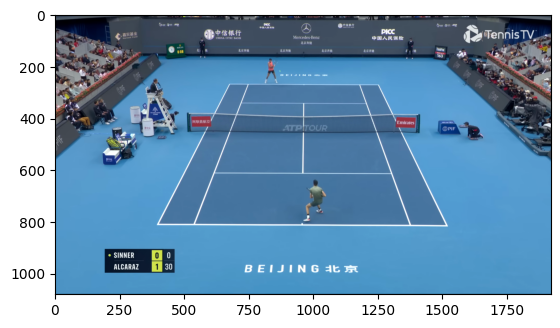

In [12]:
from groundingdino.util.inference import load_model, load_image, predict, annotate, batch_predict
import cv2
import torch
import matplotlib.pyplot as plt
from PIL import Image

model = load_model("groundingdino/config/GroundingDINO_SwinT_OGC.py", "groundingdino_swint_ogc.pth")
IMAGE_PATH = "/Users/derek/Desktop/Drone-detection-dataset/output_frames/V_DRONE_001/frame_0000.jpg"
IMAGE_PATH = "/Users/derek/Desktop/tennis_tracker/tennis_tracker/download_data/frames/Jannik Sinner vs Carlos Alcaraz For The Title! 🏆 ｜ Beijing 2024 Final Highlights [Kv_obyZNKl4]/101.png"
TEXT_PROMPT = "tennis player"
BOX_TRESHOLD = 0.35
TEXT_TRESHOLD = 0.25

img = Image.open(IMAGE_PATH)
image_source, image = load_image(IMAGE_PATH)
plt.imshow(img)


In [13]:
images = torch.stack([image, image])
boxes, logits, boxes_to_im = batch_predict(
    model=model,
    preprocessed_images=images,
    caption=TEXT_PROMPT,
    box_threshold=BOX_TRESHOLD,
    text_threshold=TEXT_TRESHOLD,
    device="cpu"
)

annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=["object"])
cv2.imwrite("annotated_image.jpg", annotated_frame)

SupervisionWarnings: annotate is deprecated: `BoxAnnotator` is deprecated and will be removed in `supervision-0.22.0`. Use `BoundingBoxAnnotator` and `LabelAnnotator` instead


True

In [14]:
boxes

tensor([[0.5224, 0.6668, 0.0469, 0.1528],
        [0.4350, 0.2030, 0.0277, 0.0925],
        [0.5224, 0.6668, 0.0469, 0.1528],
        [0.4350, 0.2030, 0.0277, 0.0925]])